In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [5]:
rain_df=pd.read_csv('../Data/rainfall.csv')
pest_df=pd.read_csv('../Data/Pesticides.csv')
temp_df=pd.read_csv('../Data/temp.csv')
yield_df=pd.read_csv('../Data/yield.csv')
yield_df_df=pd.read_csv('../Data/yield_df.csv')

In [6]:
rain_df.head()

,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327


In [40]:
for col in rain_df.select_dtypes(exclude='number').columns:
    print(col , rain_df[col].nunique())

 Area 217
average_rain_fall_mm_per_year 173


In [7]:
pest_df.head()

,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


In [38]:
for col in pest_df.select_dtypes(exclude='number').columns:
    print(col , pest_df[col].nunique())

Domain 1
Area 168
Element 1
Item 1
Unit 1


useful area year value

In [8]:
temp_df.head()

,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


In [42]:
for col in temp_df.select_dtypes(exclude='number').columns:
    print(col , temp_df[col].nunique())

country 137


In [9]:
yield_df.head()

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


In [43]:
for col in yield_df.select_dtypes(exclude='number').columns:
    print(col , yield_df[col].nunique())

Domain Code 1
Domain 1
Area 212
Element 1
Item 10
Unit 1


Useful Area and item

In [10]:
yield_df_df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [22]:
df = [yield_df, temp_df, pest_df, rain_df]
df_names = ['yield_df', 'temp_df', 'pest_df', 'rain_df']

for f, n in zip(df, df_names):
    print(n)
    print(f.columns)

yield_df
Index(['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element',
       'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value'],
      dtype='object')
temp_df
Index(['year', 'country', 'avg_temp'], dtype='object')
pest_df
Index(['Domain', 'Area', 'Element', 'Item', 'Year', 'Unit', 'Value'], dtype='object')
rain_df
Index([' Area', 'Year', 'average_rain_fall_mm_per_year'], dtype='object')


In [48]:
rain_df.head()

,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327


In [111]:
clean_yield=yield_df[['Area','Item','Year','Value']]
clean_yield.rename(columns={'Value': 'hg/ha_yield'}, inplace=True)

clean_temp=temp_df[['year','country','avg_temp']]
clean_temp.rename(columns={'year': 'Year','country':'Area'}, inplace=True)

clean_pest=pest_df[['Area','Year','Value']]
clean_pest.rename(columns={'Value':'pesticides_tonnes'},inplace=True)

clean_rain=rain_df[[' Area','Year','average_rain_fall_mm_per_year']]
clean_rain.rename(columns={' Area':'Area'},inplace=True)

In [112]:
df = clean_yield.merge(clean_rain,on=['Area','Year'],how='inner')
df = df.merge(clean_pest,on=['Area','Year'],how='inner')
df = df.merge(clean_temp,on=['Area','Year'],how='inner')

In [113]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Maize,1991,29068,1485.0,121.0,15.36
2,Albania,Maize,1992,24876,1485.0,121.0,16.06
3,Albania,Maize,1993,24185,1485.0,121.0,16.05
4,Albania,Maize,1994,25848,1485.0,201.0,16.96


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28248 entries, 0 to 28247
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28248 non-null  object 
 1   Item                           28248 non-null  object 
 2   Year                           28248 non-null  int64  
 3   hg/ha_yield                    28248 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28248 non-null  float64
 6   avg_temp                       28248 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB


In [115]:
rain_df['average_rain_fall_mm_per_year'] = (
    rain_df['average_rain_fall_mm_per_year']
    .astype(str)
    .str.strip()
    .str.replace(',', '')
    .str.replace('[^0-9.]', '', regex=True)
)

rain_df['average_rain_fall_mm_per_year'] = pd.to_numeric(
    rain_df['average_rain_fall_mm_per_year'], errors='coerce'
)

In [116]:
df.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28248.000000,28248.000000,28242.00000,28248.000000,28248.000000
mean,2001.541950,77047.863282,1149.05598,37069.136973,20.543722
std,7.052997,84950.194454,709.81215,59954.787836,6.311828
min,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,1995.000000,19918.750000,593.00000,1695.710000,16.710000
50%,2001.000000,38295.000000,1083.00000,17517.760000,21.510000
75%,2008.000000,104598.250000,1668.00000,48687.880000,26.000000
max,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [117]:
df.shape

(28248, 7)

In [118]:
df.isnull().sum()*100

Area                               0
Item                               0
Year                               0
hg/ha_yield                        0
average_rain_fall_mm_per_year    600
pesticides_tonnes                  0
avg_temp                           0
dtype: int64

<Axes: >

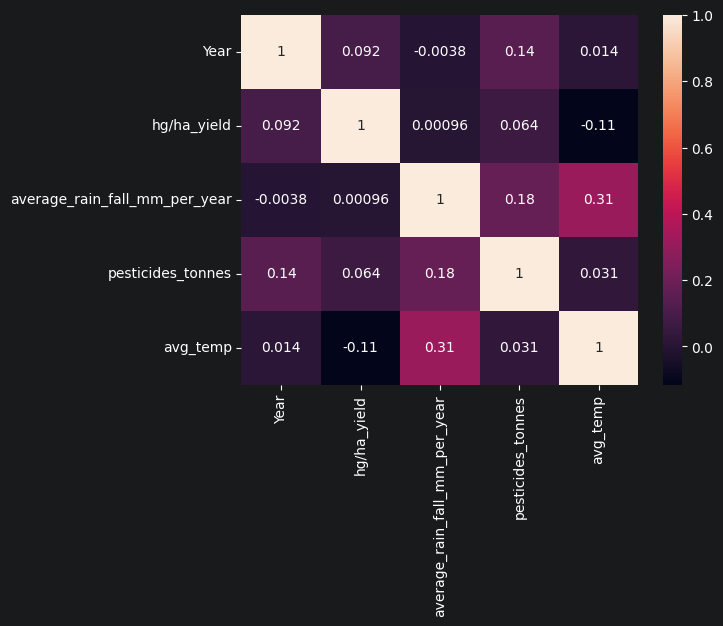

In [119]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

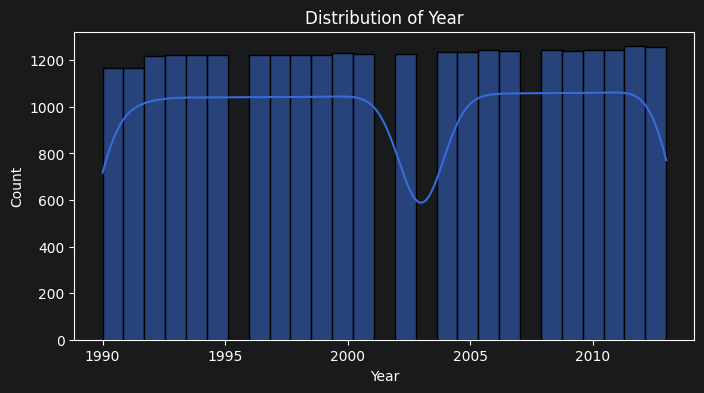

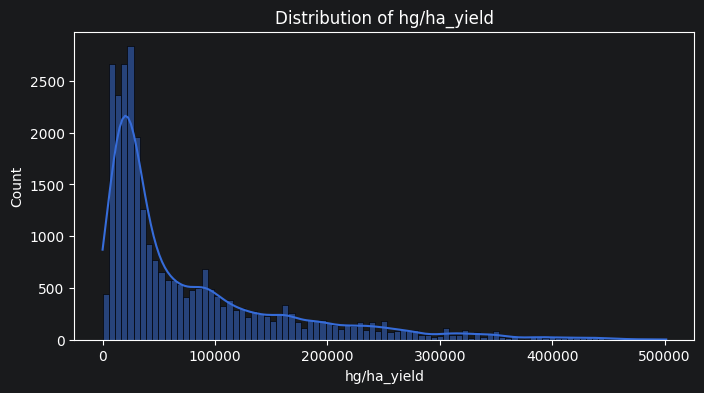

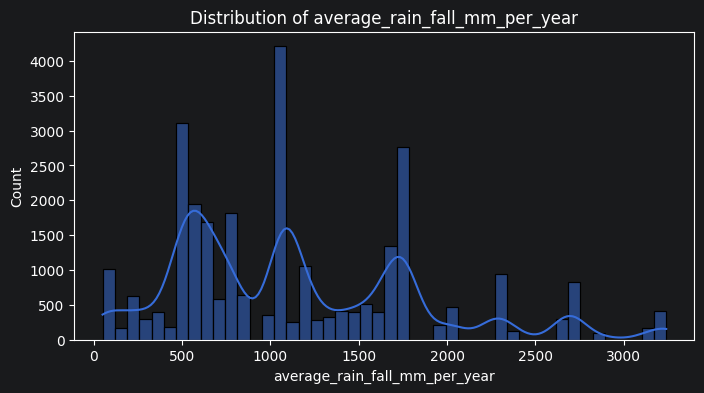

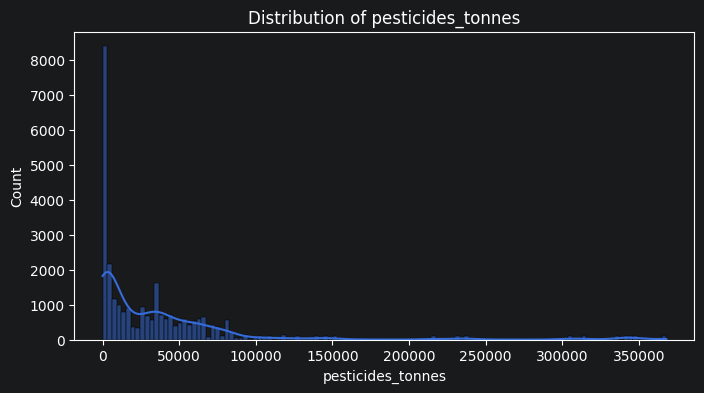

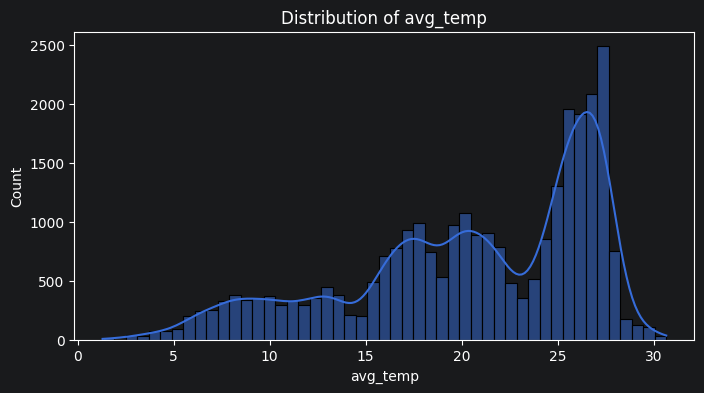

In [120]:
for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

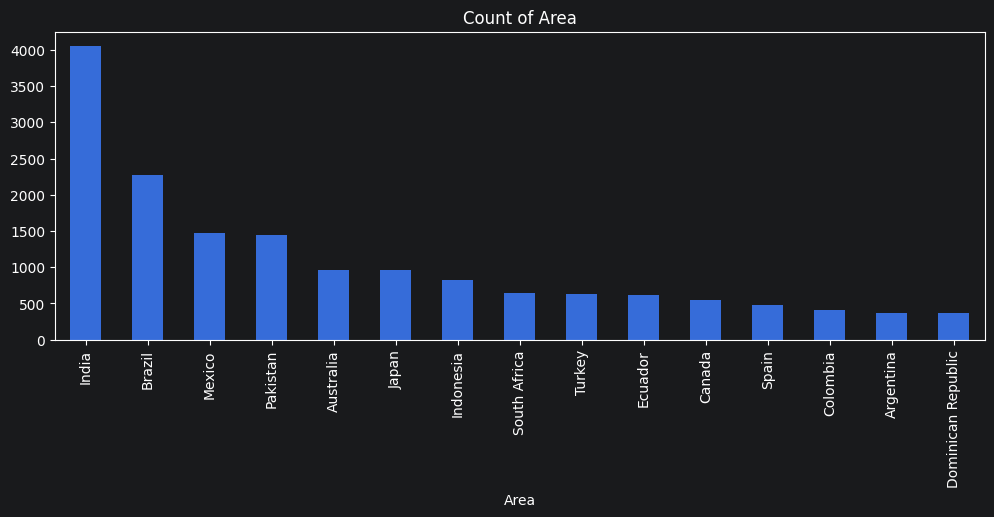

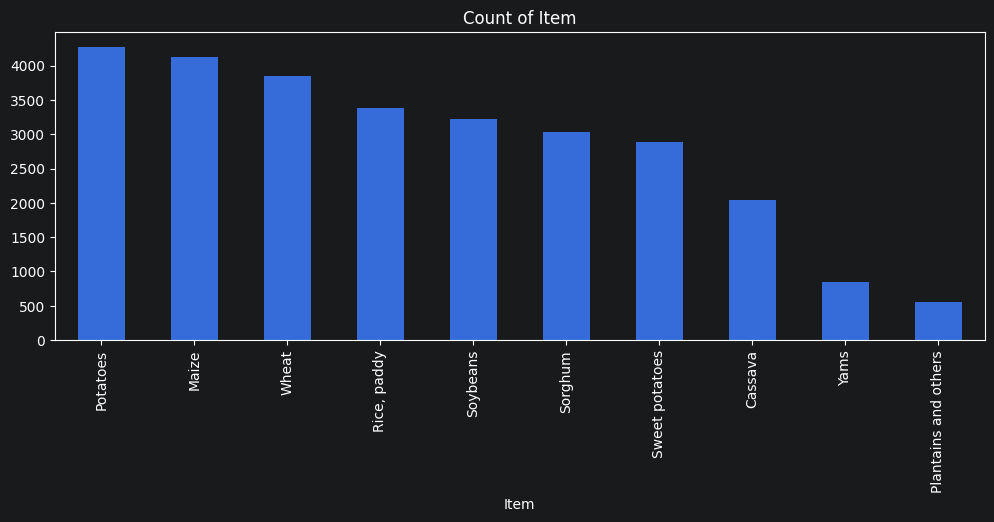

In [121]:
for col in df.select_dtypes(exclude='number').columns:
    plt.figure(figsize=(12,4))
    df[col].value_counts().head(15).plot(kind='bar')
    plt.title(f'Count of {col}')
    plt.show()

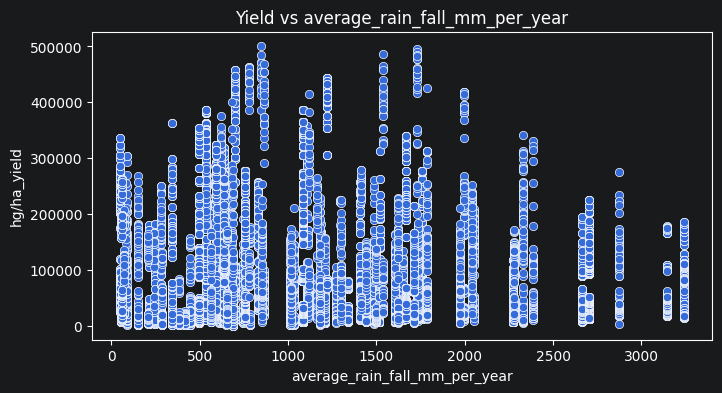

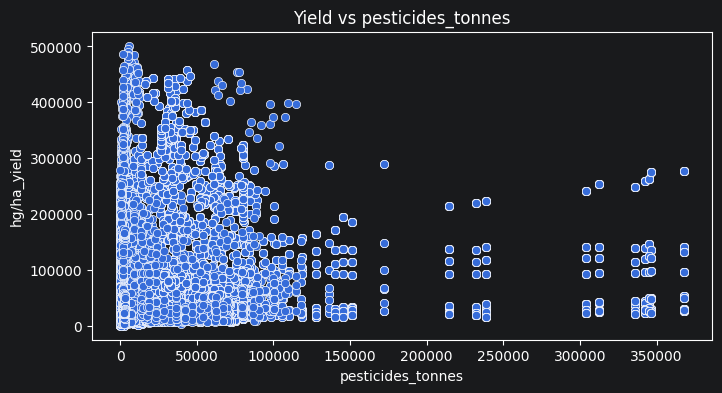

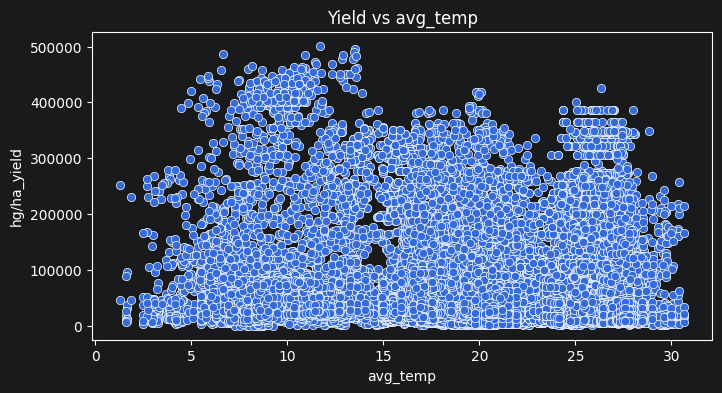

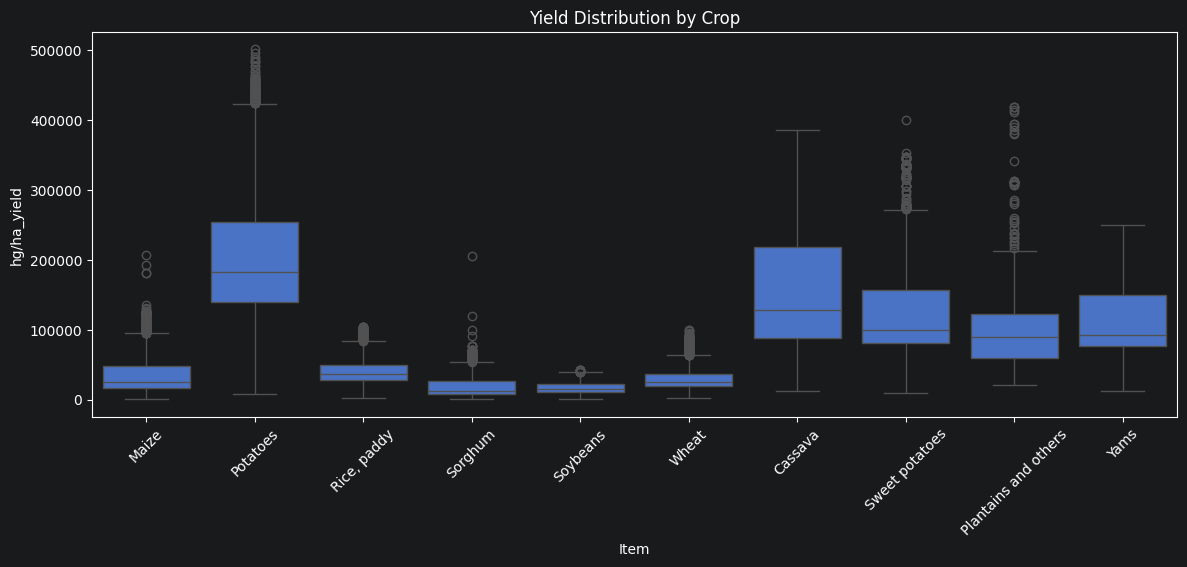

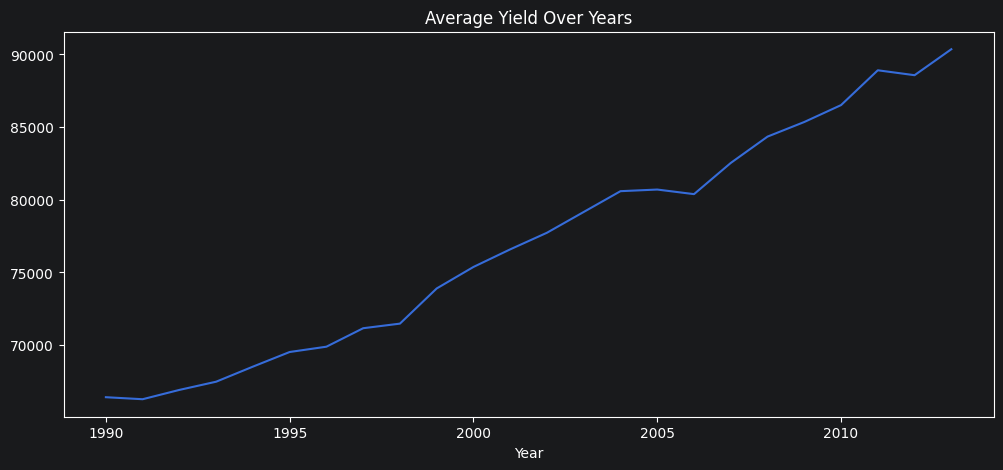

In [122]:
for col in ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']:
    plt.figure(figsize=(8,4))
    sns.scatterplot(x=df[col], y=df['hg/ha_yield'])
    plt.title(f'Yield vs {col}')
    plt.show()

# Yield by crop type
plt.figure(figsize=(14,5))
sns.boxplot(x='Item', y='hg/ha_yield', data=df)
plt.xticks(rotation=45)
plt.title('Yield Distribution by Crop')
plt.show()

# Yield trend over years
plt.figure(figsize=(12,5))
df.groupby('Year')['hg/ha_yield'].mean().plot()
plt.title('Average Yield Over Years')
plt.show()

In [128]:
from scipy.stats import skew

print(f"hg/ha_yield skewness: {skew(df['hg/ha_yield']):.2f}")
print(f"pesticides_tonnes skewness: {skew(df['pesticides_tonnes']):.2f}")
print(f"avg rainfall skewness: {skew(df['average_rain_fall_mm_per_year'])}")

hg/ha_yield skewness: 1.79
pesticides_tonnes skewness: 3.49
avg rainfall skewness: nan


In [124]:
df['hg/ha_yield_log'] = np.log1p(df['hg/ha_yield'])
df['pesticides_cbrt'] = np.cbrt(df['pesticides_tonnes'])
# Check after
print(f"Yield skewness after:       {skew(df['hg/ha_yield_log']):.2f}")
print(f"Pesticides skewness after:  {skew(df['pesticides_cbrt']):.2f}")

Yield skewness after:       -0.05
Pesticides skewness after:  0.46


In [125]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield_log,pesticides_cbrt
0,Albania,Maize,1990,36613,1485.0,121.0,16.37,10.508186,4.946087
1,Albania,Maize,1991,29068,1485.0,121.0,15.36,10.277428,4.946087
2,Albania,Maize,1992,24876,1485.0,121.0,16.06,10.121699,4.946087
3,Albania,Maize,1993,24185,1485.0,121.0,16.05,10.093529,4.946087
4,Albania,Maize,1994,25848,1485.0,201.0,16.96,10.160027,5.857766


In [130]:
df.to_csv('../Data/clean_df.csv')